In [24]:
# !git clone https://github.com/Kemsekov/kemsekov_torch

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import torch
def checkerboard(n, grid_size=4):
    """
    Generate a checkerboard pattern dataset.
    
    Parameters:
    -----------
    n : int
        Number of samples to generate
    grid_size : int
        Size of the checkerboard grid (grid_size x grid_size)
    
    Returns:
    --------
    X : ndarray of shape (n, 2)
        Feature matrix with 2D coordinates
    y : ndarray of shape (n,)
        Binary labels (0 or 1) based on checkerboard pattern
    """
    X = []
    y = []
    
    points_per_class = n // 2
    
    # Generate points for class 0 (even sum of grid coordinates)
    count_class_0 = 0
    while count_class_0 < points_per_class:
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0 and count_class_0 < points_per_class:
                    # Generate point within this square
                    x = np.random.uniform(j, j + 1)
                    y_coord = np.random.uniform(i, i + 1)
                    X.append([x, y_coord])
                    y.append(0)
                    count_class_0 += 1
    
    # Generate points for class 1 (odd sum of grid coordinates)
    count_class_1 = 0
    while count_class_1 < points_per_class:
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 1 and count_class_1 < points_per_class:
                    # Generate point within this square
                    x = np.random.uniform(j, j + 1)
                    y_coord = np.random.uniform(i, i + 1)
                    X.append([x, y_coord])
                    y.append(1)
                    count_class_1 += 1
    
    return np.array(X)[np.array(y)==0]

def concentric_circles(n, inner_radius=1.0, outer_radius=3.0, noise=0.1):
    """
    Generate a concentric circles (circle inside of a circle) dataset.
    
    Parameters:
    -----------
    n : int
        Total number of samples to generate (evenly split between classes)
    inner_radius : float
        The base radius of the inner circle (Class 0)
    outer_radius : float
        The base radius of the outer circle (Class 1)
    noise : float
        Standard deviation of Gaussian noise added to the coordinates
    
    Returns:
    --------
    X : ndarray of shape (n, 2)
        Feature matrix with 2D coordinates
    y : ndarray of shape (n,)
        Binary labels (0 for inner circle, 1 for outer circle)
    """
    points_per_class = n // 2
    
    # Generate random angles for all points
    theta_inner = np.random.uniform(0, 2 * np.pi, points_per_class)
    theta_outer = np.random.uniform(0, 2 * np.pi, points_per_class)
    
    # Convert polar to Cartesian for inner circle (Class 0)
    x_inner = inner_radius * np.cos(theta_inner)
    y_inner = inner_radius * np.sin(theta_inner)
    
    # Convert polar to Cartesian for outer circle (Class 1)
    x_outer = outer_radius * np.cos(theta_outer)
    y_outer = outer_radius * np.sin(theta_outer)
    
    # Stack features into separate class arrays
    X_inner = np.vstack((x_inner, y_inner)).T
    X_outer = np.vstack((x_outer, y_outer)).T
    
    # Combine classes into single feature matrix X and label vector y
    X = np.vstack((X_inner, X_outer))
    y = np.hstack((np.zeros(points_per_class), np.ones(points_per_class)))
    
    # Add Gaussian noise if specified
    if noise > 0:
        X += np.random.normal(0, noise, X.shape)
        
    # Shuffle the dataset so rows aren't ordered by class
    indices = np.arange(n)
    np.random.shuffle(indices)
    
    return X[indices], y[indices].astype(int)

def maze_dataset(n, grid_rows=8, grid_cols=8, path_width=0.5, noise=0.03):
    """
    Generate a 2D dense point cloud dataset shaped as a connected maze.
    
    Parameters:
    -----------
    n : int
        Number of samples to generate.
    grid_rows, grid_cols : int
        The dimensions of the discrete maze grid.
    path_width : float
        Thickness of the maze paths (0 to 1).
    noise : float
        Gaussian noise added to points to make the cloud dense.
        
    Returns:
    --------
    X : ndarray of shape (n, 2)
        Feature matrix with 2D coordinates.
    """
    # 1. Initialize walls (0=wall, 1=passage). Size ensures walls separate cells.
    r_size, c_size = grid_rows * 2 + 1, grid_cols * 2 + 1
    maze = np.zeros((r_size, c_size), dtype=int)
    
    # 2. Randomized Prim's Algorithm to guarantee a single connected tree
    start_r, start_c = 0, 0
    maze[1, 1] = 1
    walls = []
    
    # Add initial walls around the starting cell
    for dr, dc in [(-2, 0), (2, 0), (0, -2), (0, 2)]:
        nr, nc = 1 + dr, 1 + dc
        if 0 < nr < r_size and 0 < nc < c_size:
            walls.append((1 + dr//2, 1 + dc//2, nr, nc))
            
    while walls:
        # Pick a random wall
        idx = np.random.randint(0, len(walls))
        wall_r, wall_c, nr, nc = walls.pop(idx)
        
        if maze[nr, nc] == 0:
            # Connect the cell and tear down the wall
            maze[wall_r, wall_c] = 1
            maze[nr, nc] = 1
            
            # Add new neighboring walls
            for dr, dc in [(-2, 0), (2, 0), (0, -2), (0, 2)]:
                nnr, nnc = nr + dr, nc + dc
                if 0 < nnr < r_size and 0 < nnc < c_size and maze[nnr, nnc] == 0:
                    walls.append((nr + dr//2, nc + dc//2, nnr, nnc))

    # 3. Extract continuous 2D line segments from the maze matrix
    segments = []
    for r in range(r_size):
        for c in range(c_size):
            if maze[r, c] == 1:
                # Map discrete cell coordinate to continuous 2D box center
                segments.append([c, r])
                
    segments = np.array(segments, dtype=float)
    
    # 4. Uniformly sample points across the valid segments
    chosen_indices = np.random.choice(len(segments), size=n, replace=True)
    base_points = segments[chosen_indices]
    
    # 5. Spread points within the thickness of the paths
    offset = np.random.uniform(-path_width, path_width, size=(n, 2))
    X = base_points + offset
    
    # 6. Add micro-noise for organic distribution
    if noise > 0:
        X += np.random.normal(0, noise, X.shape)
        
    return X

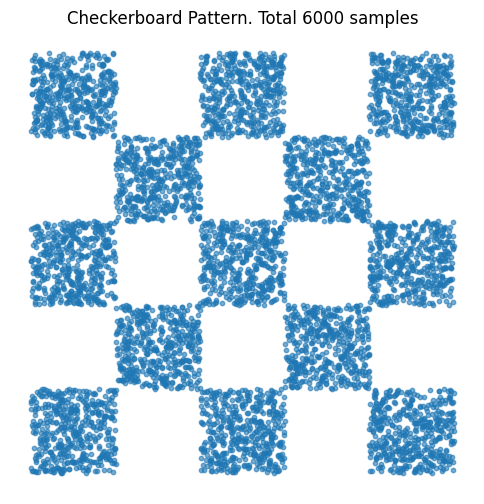

In [26]:
torch.manual_seed(3)
np.random.seed(0)

data = maze_dataset(10000,path_width=0.5,grid_cols=7,grid_rows=7)
data=checkerboard(12000,5)
# data=concentric_circles(10000)[0]
data = torch.tensor(data).float()
data-=data.mean()
data/=data.std()
plt.figure(figsize=(6,6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, s=10)
plt.title(f'Checkerboard Pattern. Total {len(data)} samples')
plt.axis("off")
plt.show()

In [27]:
from kemsekov_torch.flow_matching import FlowModel1d

torch.manual_seed(244)
fm = FlowModel1d(
    data.shape[-1],
    hidden_dim=64,
    residual_blocks=5,
    device='cpu',
    # dropout_p=0.1
)

torch.manual_seed(2)
with torch.no_grad():
    print("logprob before train",fm.log_prob(data).mean())
fm.fit(data,batch_size=512,epochs=512,debug=True)
with torch.no_grad():
    print("logprob after train",fm.log_prob(data).mean())

fm.time_scaler

logprob before train tensor(-3.1237)
Epoch 1: best_loss=6.502	best r2=-0.133
Epoch 2: best_loss=5.280	best r2=0.197
Epoch 3: best_loss=5.112	best r2=0.220
Epoch 4: best_loss=5.035	best r2=0.239
Epoch 5: best_loss=4.982	best r2=0.256
Epoch 9: best_loss=4.907	best r2=0.263
Epoch 12: best_loss=4.915	best r2=0.267
Epoch 13: best_loss=4.909	best r2=0.273
Epoch 18: best_loss=4.934	best r2=0.278
Epoch 23: best_loss=4.868	best r2=0.287
Epoch 28: best_loss=4.904	best r2=0.294
Epoch 30: best_loss=4.859	best r2=0.296
Epoch 33: best_loss=4.859	best r2=0.299
Epoch 43: best_loss=4.811	best r2=0.307
Epoch 55: best_loss=4.734	best r2=0.307
Epoch 64: best_loss=4.774	best r2=0.309
Epoch 65: best_loss=4.726	best r2=0.314
Epoch 81: best_loss=4.714	best r2=0.320
Epoch 89: best_loss=4.743	best r2=0.324
Epoch 119: best_loss=4.702	best r2=0.325
Epoch 121: best_loss=4.725	best r2=0.328
Epoch 128: best_loss=4.683	best r2=0.331
Epoch 131: best_loss=4.684	best r2=0.332
Epoch 140: best_loss=4.716	best r2=0.332
Epo

Parameter containing:
tensor([54.5616], requires_grad=True)

In [28]:
# from matplotlib import pyplot as plt

# fig,ax = plt.subplots(ncols=2,figsize=(12,5))
# ax[0].plot(fm.fit_history['loss'])
# ax[0].set_xlabel("Iteration")
# ax[0].set_ylabel("Loss")
# ax[0].set_title("Training loss")

# ax[1].plot(fm.fit_history['r2'])
# ax[1].set_xlabel("Iteration")
# ax[1].set_ylabel("R2")
# ax[1].set_title("Training metric")


In [29]:
# import matplotlib.animation as animation
# from IPython.display import Image, display

# with torch.no_grad():
#     normal_noise = torch.randn((len(data),2))
#     a,b = fm.fm.integrate(fm,normal_noise.to(fm.device),steps=32,return_intermediates=True)
#     a = a.cpu()
#     b=[i.cpu() for i in b]
#     b=[b[0]]*2+b+[b[-1]]*6
# fig, ax = plt.subplots(figsize=(6, 6))

# # Initialize scatter plot
# scatter = ax.scatter([], [], s=2, alpha=0.5, c='blue')

# # Set axis limits (adjust based on your data range)
# ax.set_xlim(-2.5, 2.5)  # Adjust based on your data
# ax.set_ylim(-2.5, 2.5)  # Adjust based on your data
# ax.set_title('With learnable TS')

# # Animation update function
# def update(frame):
#     data = b[frame][:,[0,1]]
#     scatter.set_offsets(data)
#     # ax.set_title(f'Animation Frame {frame + 1}/{len(b)}')
#     return scatter,

# # Create animation
# ani = animation.FuncAnimation(
#     fig, 
#     update, 
#     frames=len(b), 
#     interval=100,  # milliseconds between frames
#     blit=True
# )

# # Save as GIF
# ani.save('animation.gif', writer='pillow', fps=10)

# # Display in notebook
# plt.close(fig)  # Close the static figure

# display(Image(filename="animation.gif"))

In [30]:
from copy import deepcopy

fm_reflow = deepcopy(fm)
torch.manual_seed(0)
fm_reflow.reflow(data,epochs=2048,batch_size=512,lr=0.01,steps=1,debug=True)

with torch.no_grad():
    print("logprob after reflow",fm_reflow.log_prob(data).mean())

Iteration=31   loss=0.063895 forward_r2=0.9937 inverse_r2=0.9575 loss_pred_r2=-58.61
Iteration=63   loss=0.030968 forward_r2=0.9974 inverse_r2=0.9909 loss_pred_r2=-183.0
Iteration=95   loss=0.029259 forward_r2=0.9980 inverse_r2=0.9928 loss_pred_r2=-206.5
Iteration=127  loss=0.028271 forward_r2=0.9983 inverse_r2=0.9933 loss_pred_r2=-273.2
Iteration=159  loss=0.025147 forward_r2=0.9987 inverse_r2=0.9959 loss_pred_r2=-436.9
Iteration=191  loss=0.025129 forward_r2=0.9982 inverse_r2=0.9962 loss_pred_r2=-324.3
Iteration=223  loss=0.025816 forward_r2=0.9978 inverse_r2=0.9958 loss_pred_r2=-217.1
Iteration=255  loss=0.025145 forward_r2=0.9986 inverse_r2=0.9962 loss_pred_r2=-334.6
Iteration=287  loss=0.024364 forward_r2=0.9987 inverse_r2=0.9963 loss_pred_r2=-379.9
Iteration=319  loss=0.024584 forward_r2=0.9989 inverse_r2=0.9964 loss_pred_r2=-450.4
Iteration=351  loss=0.023666 forward_r2=0.9983 inverse_r2=0.9978 loss_pred_r2=-418.3
Iteration=383  loss=0.022783 forward_r2=0.9990 inverse_r2=0.9980 

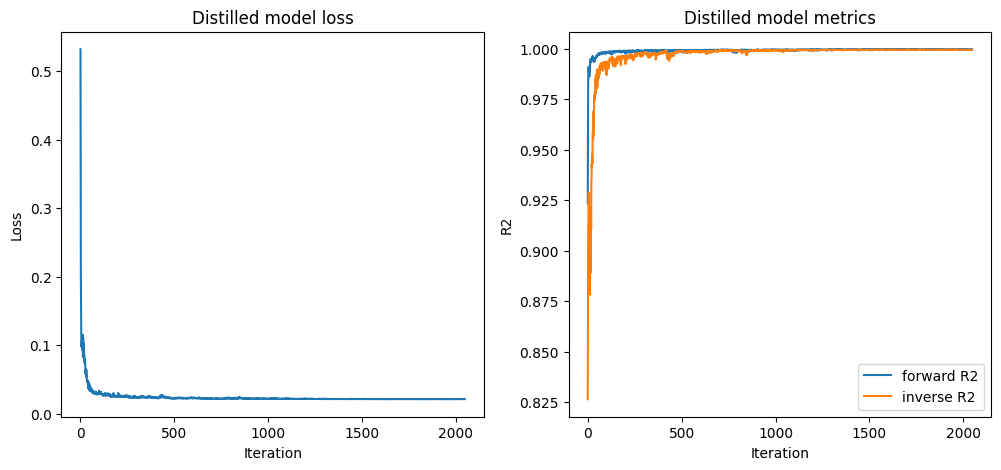

In [31]:
fig,ax = plt.subplots(ncols=2,figsize=(12,5))
ax[0].plot(fm_reflow.reflow_history['loss'])
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Distilled model loss")

ax[1].plot(fm_reflow.reflow_history['forward_r2'],label='forward R2')
ax[1].plot(fm_reflow.reflow_history['inverse_r2'],label='inverse R2')
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("R2")
ax[1].set_title("Distilled model metrics")
ax[1].legend()

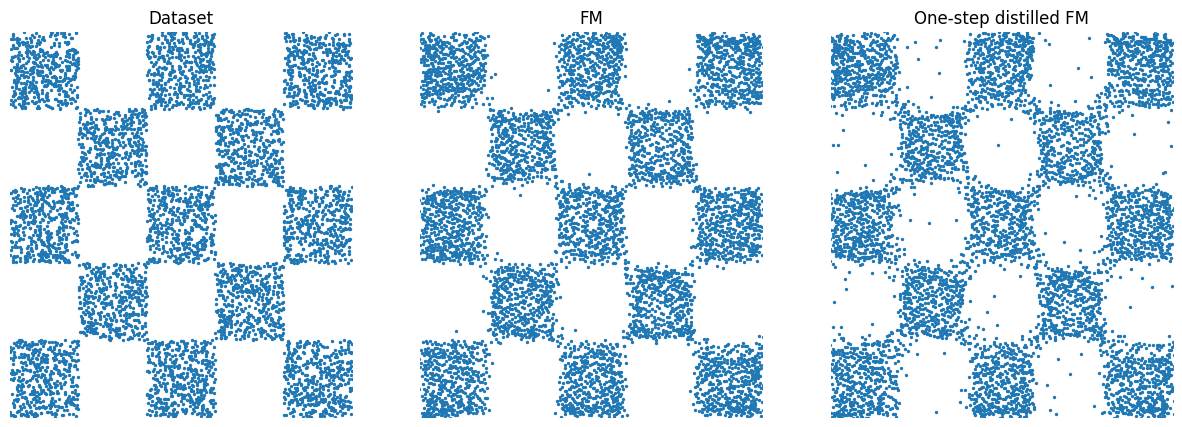

In [32]:
from matplotlib import pyplot as plt
import numpy as np

n = len(data)
with torch.no_grad():
    fm_sample = fm.sample(n,steps=32,sobol=True).cpu()
    reflow_sample = fm_reflow.sample(n,sobol=True).cpu()
    

ax = plt.subplots(ncols=3,figsize=(15,5))[1]

ax[0].scatter(data[:,0],data[:,1],s=2)
ax[0].set_xlim(data[:,0].min(),data[:,0].max())
ax[0].set_ylim(data[:,1].min(),data[:,1].max())
ax[0].set_title("Dataset")
ax[0].axis("off")

ax[1].scatter(fm_sample[:,0],fm_sample[:,1],s=2)
ax[1].set_xlim(data[:,0].min(),data[:,0].max())
ax[1].set_ylim(data[:,1].min(),data[:,1].max())
ax[1].set_title(f"FM")
ax[1].axis("off")

ax[2].scatter(reflow_sample[:,0],reflow_sample[:,1],s=2)
ax[2].set_xlim(data[:,0].min(),data[:,0].max())
ax[2].set_ylim(data[:,1].min(),data[:,1].max())
ax[2].set_title(f"One-step distilled FM")
ax[2].axis("off")
plt.show()

logprob after reflow tensor(-1.8738)
logprob after reflow+freeze tensor(-1.8723)


(np.float64(-1.6690471172332764),
 np.float64(1.6731092929840088),
 np.float64(-1.6691020727157593),
 np.float64(1.672673225402832))

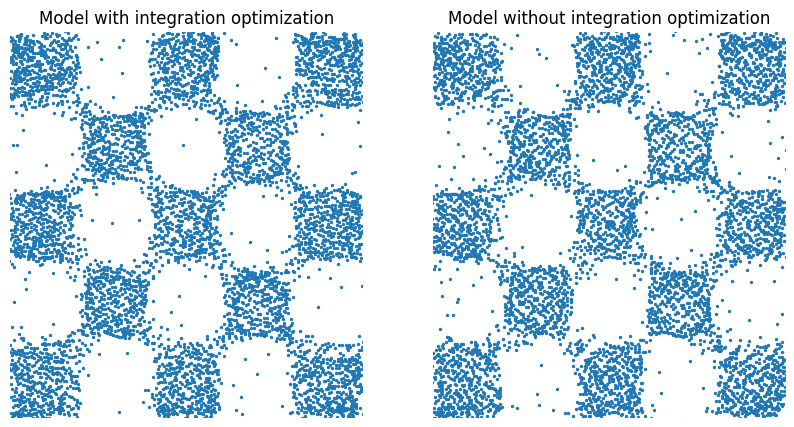

In [33]:
from copy import deepcopy

fm_reflow_freeze = deepcopy(fm)
torch.manual_seed(0)
fm_reflow_freeze.reflow(data,epochs=2048,batch_size=512,lr=0.01,freeze_integrator=True,steps=1)

with torch.no_grad():
    print("logprob after reflow",fm_reflow.log_prob(data).mean())
    print("logprob after reflow+freeze",fm_reflow_freeze.log_prob(data).mean())

with torch.no_grad():
    freeze_reflow_sample = fm_reflow_freeze.sample(n,sobol=True).cpu()
ax = plt.subplots(ncols=2,figsize=(10,5))[1]

ax[0].scatter(reflow_sample[:,0],reflow_sample[:,1],s=2)
ax[0].set_xlim(data[:,0].min(),data[:,0].max())
ax[0].set_ylim(data[:,1].min(),data[:,1].max())
ax[0].set_title("Model with integration optimization")
ax[0].axis("off")

ax[1].scatter(freeze_reflow_sample[:,0],freeze_reflow_sample[:,1],s=2)
ax[1].set_xlim(data[:,0].min(),data[:,0].max())
ax[1].set_ylim(data[:,1].min(),data[:,1].max())
ax[1].set_title("Model without integration optimization")
ax[1].axis("off")

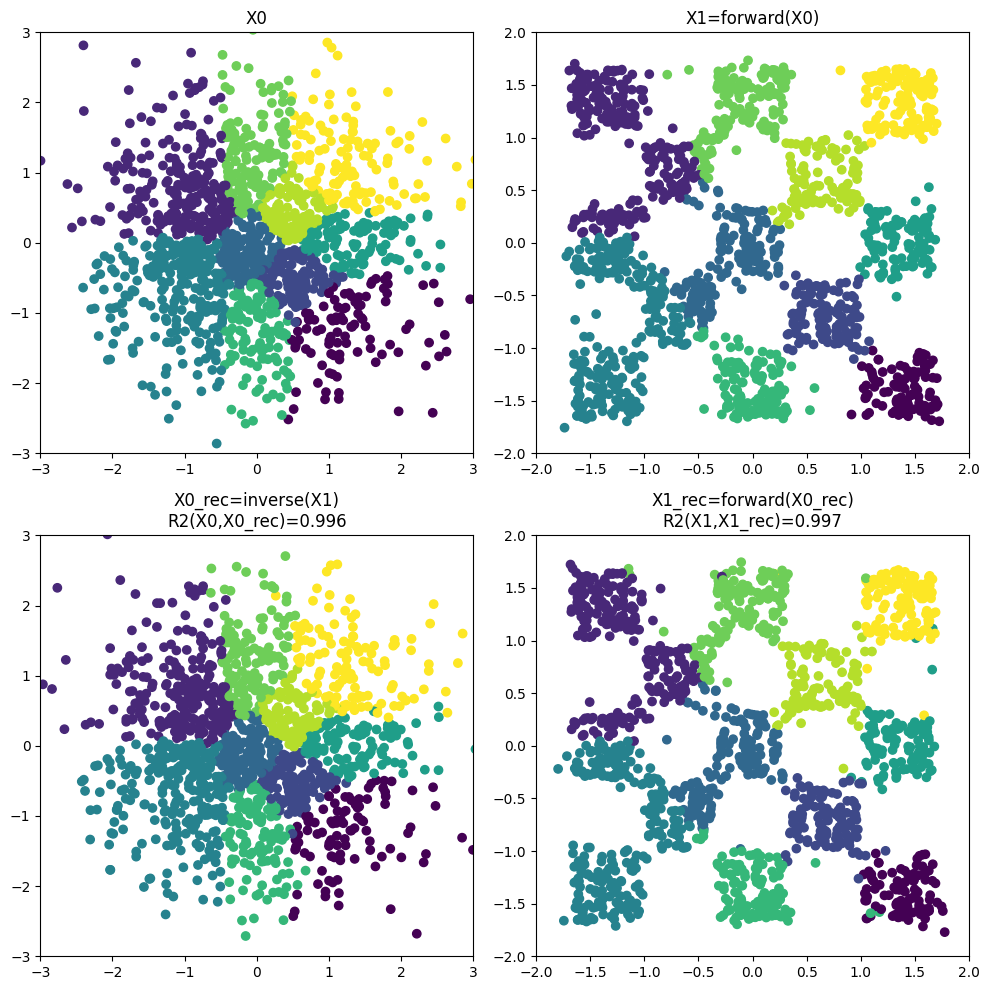

In [34]:
# check inevitability of the model
from kemsekov_torch.fast_pytorch_kmeans.kmeans import KMeans
from kemsekov_torch.metrics import r2_score


x0 = torch.randn((1500,2))

with torch.no_grad():
    x1 = fm_reflow.to_target(x0)
    x0_1 = fm_reflow.to_prior(x1)
    x1_0 = fm_reflow.to_target(x0_1)

c = KMeans(n_clusters=10).fit_predict(x1)
x0_rec_r2 = r2_score(x0,x0_1)
x1_rec_r2 = r2_score(x1,x1_0)

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.scatter(x0[:,0],x0[:,1],c=c)
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title("X0")

plt.subplot(2,2,2)
plt.scatter(x1[:,0],x1[:,1],c=c)
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.title("X1=forward(X0)")

plt.subplot(2,2,3)
plt.scatter(x0_1[:,0],x0_1[:,1],c=c)
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title(f"X0_rec=inverse(X1)\nR2(X0,X0_rec)={x0_rec_r2:0.3f}")

plt.subplot(2,2,4)
plt.scatter(x1_0[:,0],x1_0[:,1],c=c)
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.title(f"X1_rec=forward(X0_rec)\nR2(X1,X1_rec)={x1_rec_r2:0.3f}")

plt.tight_layout()

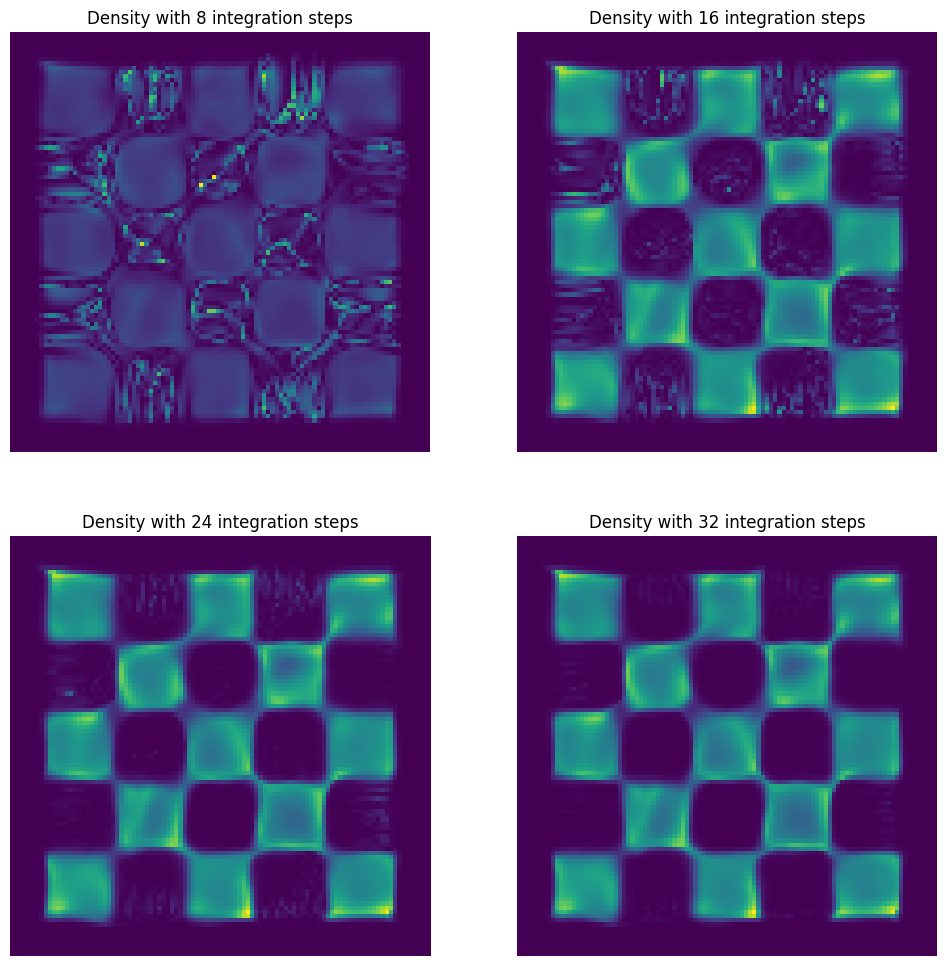

In [35]:
X = torch.linspace(-2,2,100)
Y = torch.linspace(-2,2,100)
grid = torch.stack(torch.meshgrid([X,Y],indexing="ij"),-1)
model = fm

plt.figure(figsize=(12,12))
for i,s in enumerate([8,16,24,32]):
    fm.default_steps=s
    with torch.no_grad():
        x = grid.view(-1,2)
        probs = model.log_prob(x,eps=0.01).view(grid.shape[:-1]).cpu()
    plt.subplot(2,2,i+1)
    plt.imshow((probs.T).sigmoid())
    plt.axis('off')
    plt.title(f"Density with {fm.default_steps} integration steps")

Text(0.5, 1.0, 'Distilled model density')

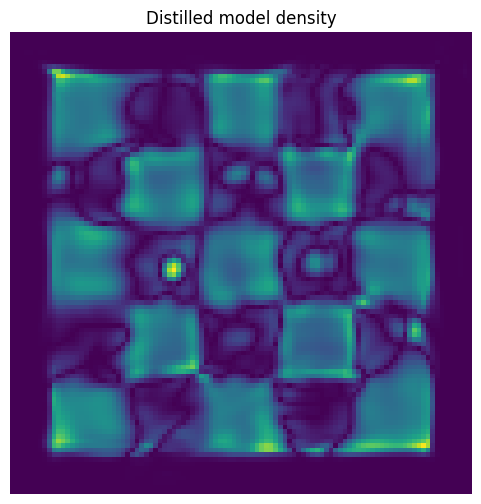

In [36]:
model = fm_reflow

plt.figure(figsize=(6,6))
with torch.no_grad():
    x = grid.view(-1,2)
    probs = model.log_prob(x,eps=0.01).view(grid.shape[:-1]).cpu()
plt.imshow((probs.T).sigmoid())
plt.axis('off')
plt.title(f"Distilled model density")

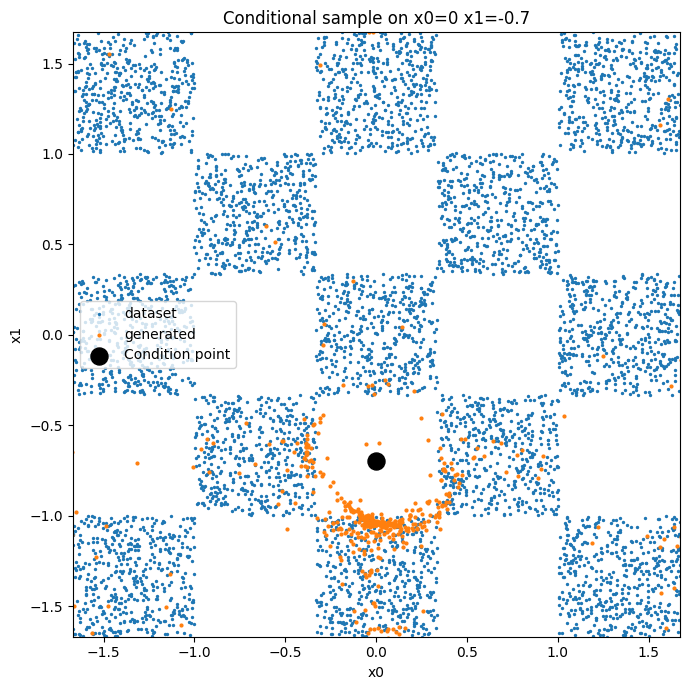

In [37]:
x0 = 0
x1 = -0.7
def constraint(x):
    a = ((x[:,0]-x0)**2).mean()
    b = ((x[:,1]-x1)**2).mean()
    return a+b

constrained_samples = fm_reflow.constrained_sample(
    constraint=constraint,
    num_samples=500,
    noise_scale=0.0,
    steps=1,
    mode_closeness_weight=0
)[:,:3].cpu()

plt.figure(figsize=(7,7))
plt.scatter(data[:,0],data[:,1],s=2,label='dataset')
plt.scatter(constrained_samples[:,0],constrained_samples[:,1],s=4,label='generated')
plt.scatter([x0],[x1],s=150,c='black',label='Condition point')
plt.title(f"Conditional sample on x0={x0} x1={x1}")
plt.xlabel("x0")
plt.ylabel("x1")
plt.xlim(data[:,0].min(),data[:,0].max())
plt.ylim(data[:,1].min(),data[:,1].max())
plt.tight_layout()
plt.legend()

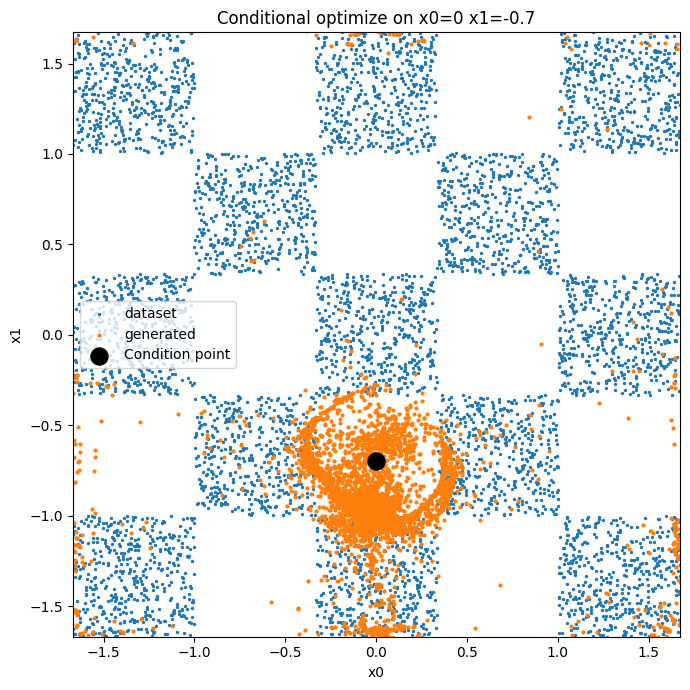

In [38]:
constrained_samples = fm_reflow.constrained_optimize(
    constraint=constraint,
    data=data,
    noise_scale=0.0,
    steps=2,
    mode_closeness_weight=0
)[:,:3].cpu()

plt.figure(figsize=(7,7))
plt.scatter(data[:,0],data[:,1],s=2,label='dataset')
plt.scatter(constrained_samples[:,0],constrained_samples[:,1],s=4,label='generated')
plt.scatter([x0],[x1],s=150,c='black',label='Condition point')
plt.title(f"Conditional optimize on x0={x0} x1={x1}")
plt.xlabel("x0")
plt.ylabel("x1")
plt.xlim(data[:,0].min(),data[:,0].max())
plt.ylim(data[:,1].min(),data[:,1].max())
plt.tight_layout()
plt.legend()

(np.float64(-3.5), np.float64(3.5), np.float64(-3.5), np.float64(3.5))

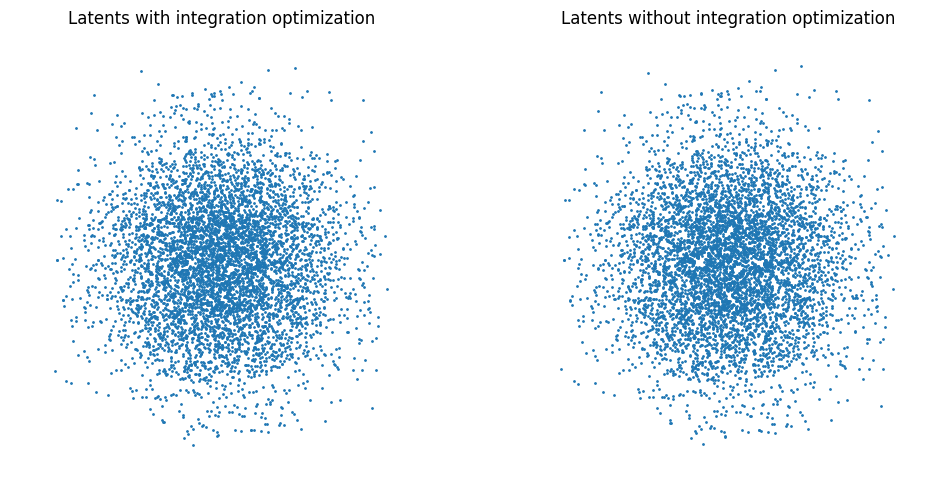

In [39]:
with torch.no_grad():
    latent_freeze = fm_reflow_freeze.to_prior(data)
    latent_reflow = fm_reflow.to_prior(data)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(latent_reflow[:,0],latent_reflow[:,1],s=1)
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)
plt.title("Latents with integration optimization")
plt.axis('off')

plt.subplot(1,2,2)
plt.scatter(latent_freeze[:,0],latent_freeze[:,1],s=1)
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)
plt.title("Latents without integration optimization")
plt.axis('off')


For given random vector

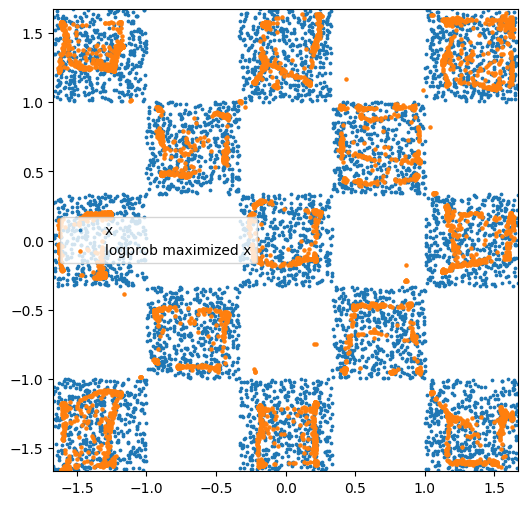

In [40]:
data_opt,loss = fm_reflow.optimize(data)
data_opt=data_opt.detach()
plt.figure(figsize=(6,6))
plt.scatter(data[:,0],data[:,1],s=3,label='x')
plt.scatter(data_opt[:,0],data_opt[:,1],s=5,label='logprob maximized x')
plt.xlim(data[:,0].min(),data[:,0].max())
plt.ylim(data[:,1].min(),data[:,1].max())
plt.legend()

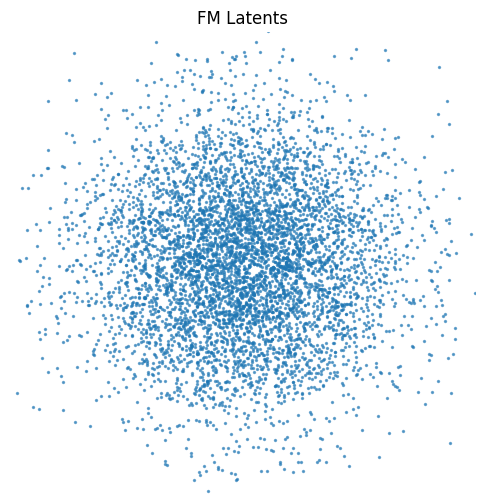

In [41]:
# prior = torch.randn_like(data)
with torch.no_grad():
    prior = fm.to_prior(data)
plt.figure(figsize=(6,6))
plt.scatter(prior[:, 0], prior[:, 1], alpha=0.6, s=2)
plt.axis('off')
plt.title("FM Latents")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.show()

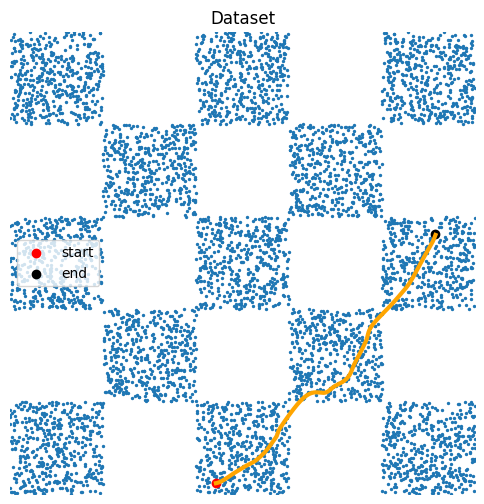

In [45]:
import random

a = data[random.randint(0,1000)]
b = data[random.randint(0,1000)]

model = fm_reflow
model.freeze() # speed up computations by removing grads for model

ab=model.interpolate(a,b,torch.linspace(0,1,1028))

ab_before = ab.clone()
ab_before=ab_before[:,0]
plt.figure(figsize=(6,6))
plt.scatter(data[:,0],data[:,1],s=2)
plt.xlim(data[:,0].min(),data[:,0].max())
plt.ylim(data[:,1].min(),data[:,1].max())
plt.title("Dataset")
plt.axis("off")
# for prev,next in zip(ab[:-1],ab[1:]):
plt.plot(ab_before[:,0],ab_before[:,1],c='orange',linewidth=3)
plt.scatter([a[0]],[a[1]],c='red',label='start')
plt.scatter([b[0]],[b[1]],c='black',label='end')
# plt.scatter(interp[:,0],interp[:,1],c='yellow',label='interp')
plt.legend()